In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [17]:
df = pd.read_csv('ecommerce_data.csv')
print(df.head())

   InvoiceNo StockCode           Description  Quantity InvoiceDate  UnitPrice  \
0  INV334053   SC28289         WICKER BASKET         9  2023-05-06       3.00   
1  INV131244   SC22280  BAMBOO CUTTING BOARD        14  2023-01-17       1.75   
2  INV731262   SC13478       COTTON TOTE BAG         8  2023-09-16       1.00   
3  INV331148   SC68878         WICKER BASKET        18  2023-08-03       3.00   
4  INV895667   SC30926  BAMBOO CUTTING BOARD         9  2023-01-04       1.75   

  CustomerID  Country  
0   CUST0001  Germany  
1   CUST0002  Germany  
2   CUST0002  Germany  
3   CUST0003    Italy  
4   CUST0003    Italy  


In [18]:
df = df.dropna()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print(df.shape)

(2351, 9)


In [19]:
last_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (last_date - x.max()).days),
    Frequency = ('InvoiceNo', 'count'),
    Monetary = ('TotalPrice', 'sum')
).reset_index()

print(rfm.head())

  CustomerID  Recency  Frequency  Monetary
0   CUST0001      239          1     27.00
1   CUST0002      106          2     32.50
2   CUST0003      150          4    122.75
3   CUST0004       55          6    140.50
4   CUST0005       53          3     45.00


In [20]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

model = KMeans(n_clusters=3, random_state=0)
rfm['Cluster'] = model.fit_predict(rfm_scaled)

print(rfm['Cluster'].value_counts())

Cluster
2    206
0    203
1     91
Name: count, dtype: int64


/tmp/ipykernel_722/360272774.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.index, y=country_sales.values, palette='Blues_d')


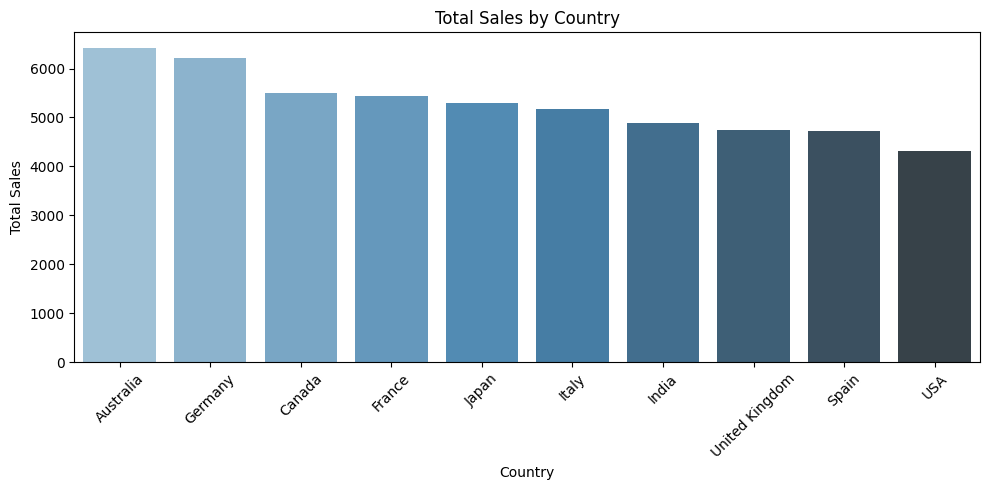

In [21]:
# Graph 1 - Sales by Country
plt.figure(figsize=(10, 5))
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
sns.barplot(x=country_sales.index, y=country_sales.values, palette='Blues_d')
plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

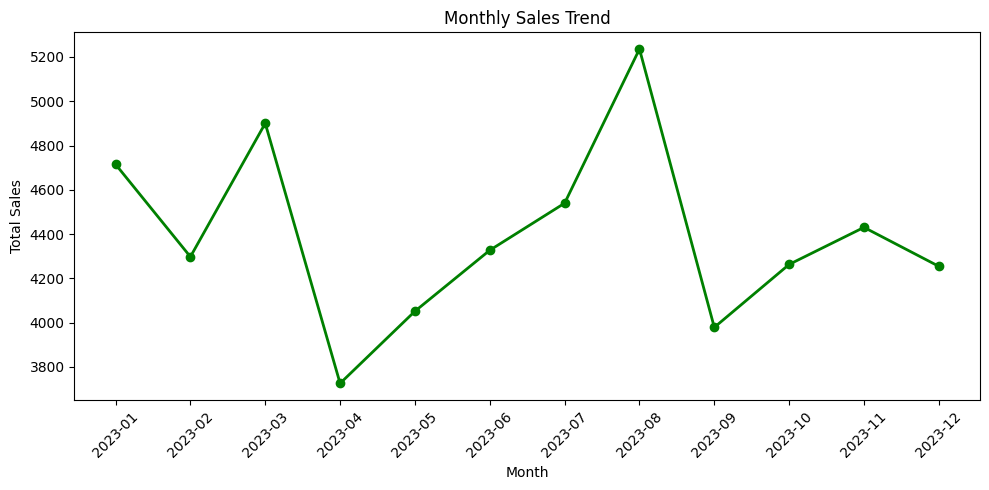

In [22]:
# Graph 2 - Monthly Sales Trend
plt.figure(figsize=(10, 5))
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly = df.groupby('Month')['TotalPrice'].sum()
plt.plot(monthly.index, monthly.values, marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_722/2245474402.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Set2')


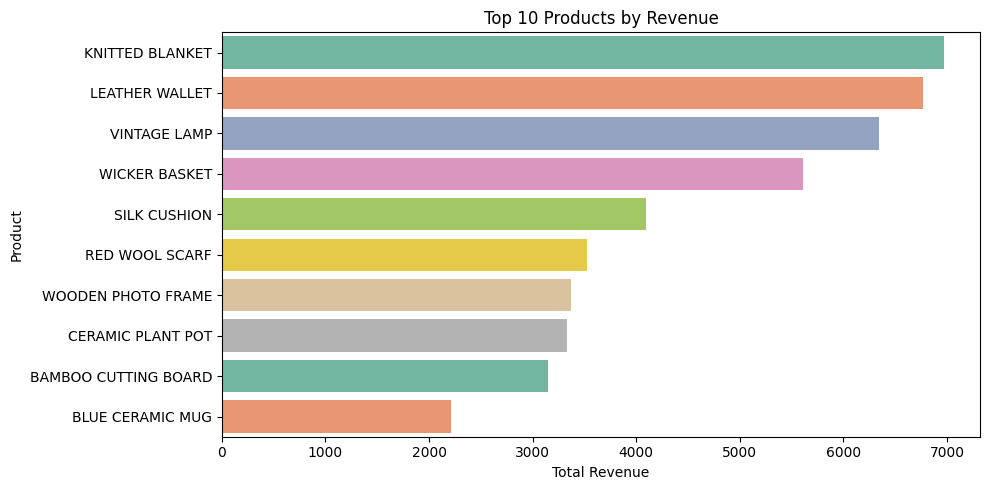

In [23]:
# Graph 3 - Top 10 Products
plt.figure(figsize=(10, 5))
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='Set2')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [24]:
print("="*55)
print("   CUSTOMER SEGMENTATION PROJECT - CONCLUSIONS")
print("="*55)

print(f"""
PROJECT OVERVIEW:
-----------------
Dataset    : E-Commerce Transactions
customers  : {rfm['CustomerID'].nunique()}
Technique  : RFM Analysis + KMeans Clustering

KEY FINDINGS:
-------------
1. CUSTOMER SEGMENTS:
{rfm['Cluster'].value_counts().to_string()}

2. TOP COUNTRY BY SALES:
{df.groupby('Country')['TotalPrice'].sum().idxmax()}

3. BEST SELLING PRODUCT:
{df.groupby('Description')['TotalPrice'].sum().idxmax()}

4. TOTAL REVENUE GENERATED:
Rs. {df['TotalPrice'].sum().round(2)}

BUSINESS RECOMMENDATIONS:
--------------------------
Cluster 0 - Regular Customers:
  > Send discount coupons to increase purchase frequency

Cluster 1 - VIP Customers:
  > Offer loyalty rewards and premium support

Cluster 2 - Lost Customers:
  > Launch win-back email campaigns with special offers
""")
print("="*55)
print("Analysis Complete!")
print("="*55)

   CUSTOMER SEGMENTATION PROJECT - CONCLUSIONS

PROJECT OVERVIEW:
-----------------
Dataset    : E-Commerce Transactions
customers  : 500
Technique  : RFM Analysis + KMeans Clustering

KEY FINDINGS:
-------------
1. CUSTOMER SEGMENTS:
Cluster
2    206
0    203
1     91

2. TOP COUNTRY BY SALES:
Australia

3. BEST SELLING PRODUCT:
KNITTED BLANKET

4. TOTAL REVENUE GENERATED:
Rs. 52719.45

BUSINESS RECOMMENDATIONS:
--------------------------
Cluster 0 - Regular Customers:
  > Send discount coupons to increase purchase frequency

Cluster 1 - VIP Customers:
  > Offer loyalty rewards and premium support

Cluster 2 - Lost Customers:
  > Launch win-back email campaigns with special offers

Analysis Complete!
